# 📊 Live Prediction Monitoring

This notebook tracks the health and accuracy of the MLB pitch prediction model in production.

**What we monitor:**
- **Data Quality** — valid prediction rate, `Inf` surprisal flags, sample gate coverage
- **Calibration** — are predicted probabilities well-calibrated? (reliability diagrams)
- **Surprisal Distribution** — is the tweet threshold well-tuned?
- **Prediction Accuracy** — overall and per-class accuracy, confusion analysis
- **Pitcher Coverage** — which pitchers pass the minimum sample gate?

The final section is **stubbed for W&B integration** — once we've established which metrics matter, we'll wire them into live run logging.

> **Data source:** `data/pitches.db → live_predictions` table, populated in real-time by `src/live_game_tracker.py`

In [1]:
import sys
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

# ── paths ──────────────────────────────────────────────────────────────────
ROOT = Path("/Users/michael/Documents/Data Projects/mlb-pitch-bot")
DB_PATH = ROOT / "data" / "pitches.db"

# ── styling ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#c9d1d9",
    "grid.color":       "#21262d",
    "grid.linestyle":   "--",
    "grid.linewidth":   0.6,
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family":      "sans-serif",
})

FAMILY_COLORS = {
    "Fastball": "#f78166",
    "Breaking": "#79c0ff",
    "Offspeed": "#56d364",
    "Other":    "#8b949e",
}
SURPRISAL_THRESHOLD = 2.5
MIN_PITCHER_SAMPLE  = 75

print(f"DB: {DB_PATH}  (exists={DB_PATH.exists()})")

DB: /Users/michael/Documents/Data Projects/mlb-pitch-bot/data/pitches.db  (exists=True)


In [2]:

# ── load live_predictions ──────────────────────────────────────────────────
with sqlite3.connect(DB_PATH) as conn:
    lp = pd.read_sql_query("""
        SELECT
            lp.*,
            p.pitcher AS pitcher_name
        FROM live_predictions lp
        LEFT JOIN (
            SELECT DISTINCT pitcher_id, pitcher FROM pitches
        ) p ON lp.pitcher_id = p.pitcher_id
        ORDER BY lp.timestamp
    """, conn, parse_dates=["timestamp"])

# ── coerce types — SQLite can return object/bytes dtype ───────────────────
for col in ["prob_fastball", "prob_breaking", "prob_offspeed", "surprisal",
            "pitcher_sample_n", "count_sample_n"]:
    lp[col] = pd.to_numeric(lp[col], errors="coerce")

# ── derived columns ────────────────────────────────────────────────────────
lp["date"] = lp["timestamp"].dt.date.astype(str)

prob_sum = lp[["prob_fastball","prob_breaking","prob_offspeed"]].sum(axis=1)
lp["probs_valid"] = (
    prob_sum.between(0.9, 1.1)
    & ~lp[["prob_fastball","prob_breaking","prob_offspeed"]].eq(0).all(axis=1)
)
lp["surprisal_finite"] = np.isfinite(lp["surprisal"])

# predicted family = argmax — only compute on rows with valid probs
prob_cols = lp[["prob_fastball","prob_breaking","prob_offspeed"]]
col_to_family = {"prob_fastball": "Fastball", "prob_breaking": "Breaking", "prob_offspeed": "Offspeed"}
lp["predicted_family"] = np.where(
    lp["probs_valid"],
    prob_cols.fillna(0).idxmax(axis=1).map(col_to_family),
    pd.NA
)
lp["correct"] = lp["predicted_family"] == lp["actual_pitch_family"]

print(f"Total rows: {len(lp):,}")
print(f"Date range: {lp['date'].min()} → {lp['date'].max()}")
print(f"Pitchers seen: {lp['pitcher_id'].nunique()}")
print(f"Valid prob rows: {lp['probs_valid'].sum():,} ({lp['probs_valid'].mean():.1%})")
lp.head(3)


Total rows: 447
Date range: 2026-04-05 → 2026-04-14
Pitchers seen: 167
Valid prob rows: 311 (69.6%)


,id,timestamp,game_pk,play_id,pitcher_id,batter_id,actual_pitch_family,prob_fastball,prob_breaking,prob_offspeed,surprisal,pitcher_sample_n,count_sample_n,pitcher_name,date,probs_valid,surprisal_finite,predicted_family,correct
0,1,2026-04-05 17:18:48,824459,90139106-fd2b-3fe6-9b7f-4d8a684c6f13,677944,664023,Fastball,0.628003,0.371997,0.0,0.671157,NaN,NaN,Slade Cecconi,2026-04-05,True,True,Fastball,True
1,2,2026-04-05 17:24:20,824459,d6b04635-be3d-37ce-ba0a-5024f5904296,665795,608070,Offspeed,0.000000,1.000000,0.0,inf,NaN,NaN,Edward Cabrera,2026-04-05,True,False,Breaking,False
2,3,2026-04-05 17:30:24,824459,0f0d9b83-55d5-38e8-b6e1-88b3e8ee5e6c,677944,663538,Fastball,0.204281,0.795719,0.0,2.291371,NaN,NaN,Slade Cecconi,2026-04-05,True,True,Breaking,False


## 1. Data Quality

Before drawing any conclusions about model performance, we need to confirm the data pipeline is healthy.

Key checks:
- **Valid probability rate** — probs should sum to ~1.0; all-zero rows indicate a logging bug
- **Infinite surprisal** — `surprisal = -log2(p_actual)` is `Inf` when `p_actual = 0.0`; this means the model assigned literally zero probability to the pitch that was thrown
- **Sample gate coverage** — rows logged before/after the `MIN_PITCHER_SAMPLE=75` gate was deployed

In [3]:

dq = lp.groupby("date").agg(
    total_rows       = ("id", "count"),
    valid_probs      = ("probs_valid", "sum"),
    finite_surprisal = ("surprisal_finite", "sum"),
    has_sample_n     = ("pitcher_sample_n", lambda s: s.notna().sum()),
).assign(
    valid_pct       = lambda d: (d["valid_probs"]      / d["total_rows"] * 100).round(1),
    finite_surp_pct = lambda d: (d["finite_surprisal"] / d["total_rows"] * 100).round(1),
    sample_n_pct    = lambda d: (d["has_sample_n"]     / d["total_rows"] * 100).round(1),
).reset_index()

def _flag(val):
    return "background-color: #3d1f1f" if val < 80 else ""

display(
    dq.style
      .map(_flag, subset=["finite_surp_pct"])   # applymap → map in pandas ≥ 2.1
      .format({"valid_pct": "{:.1f}%", "finite_surp_pct": "{:.1f}%", "sample_n_pct": "{:.1f}%"})
      .set_caption("Daily data quality summary")
)

print(f"\nOverall valid prob rate : {lp['probs_valid'].mean()*100:.1f}%")
print(f"Overall finite surprisal: {lp['surprisal_finite'].mean()*100:.1f}%")
print(f"Rows with pitcher_sample_n populated: {lp['pitcher_sample_n'].notna().sum()} / {len(lp)}")


,date,total_rows,valid_probs,finite_surprisal,has_sample_n,valid_pct,finite_surp_pct,sample_n_pct
0,2026-04-05,238,238,149,0,100.0%,62.6%,0.0%
1,2026-04-06,5,5,4,0,100.0%,80.0%,0.0%
2,2026-04-09,5,5,5,0,100.0%,100.0%,0.0%
3,2026-04-10,64,12,12,0,18.8%,18.8%,0.0%
4,2026-04-11,84,0,1,0,0.0%,1.2%,0.0%
5,2026-04-13,4,4,4,4,100.0%,100.0%,100.0%
6,2026-04-14,47,47,47,47,100.0%,100.0%,100.0%



Overall valid prob rate : 69.6%
Overall finite surprisal: 49.7%
Rows with pitcher_sample_n populated: 51 / 447


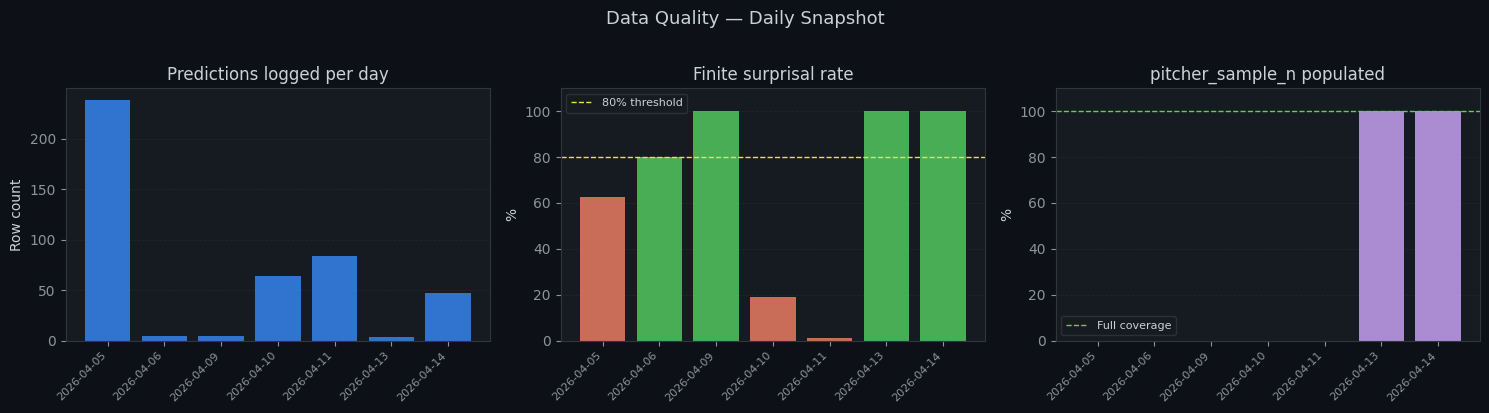

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Data Quality — Daily Snapshot", fontsize=13, y=1.02)

dates = dq["date"].tolist()
x = range(len(dates))

# panel 1 — row volume
ax = axes[0]
ax.bar(x, dq["total_rows"], color="#388bfd", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(dates, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Row count")
ax.set_title("Predictions logged per day")
ax.yaxis.grid(True); ax.set_axisbelow(True)

# panel 2 — finite surprisal %
ax = axes[1]
colors = ["#f78166" if v < 80 else "#56d364" for v in dq["finite_surp_pct"]]
ax.bar(x, dq["finite_surp_pct"], color=colors, alpha=0.8)
ax.axhline(80, color="#f0e040", linestyle="--", linewidth=1, label="80% threshold")
ax.set_xticks(x); ax.set_xticklabels(dates, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("%")
ax.set_title("Finite surprisal rate")
ax.set_ylim(0, 110); ax.legend(fontsize=8)
ax.yaxis.grid(True); ax.set_axisbelow(True)

# panel 3 — sample_n coverage
ax = axes[2]
ax.bar(x, dq["sample_n_pct"], color="#d2a8ff", alpha=0.8)
ax.axhline(100, color="#56d364", linestyle="--", linewidth=1, label="Full coverage")
ax.set_xticks(x); ax.set_xticklabels(dates, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("%")
ax.set_title("pitcher_sample_n populated")
ax.set_ylim(0, 110); ax.legend(fontsize=8)
ax.yaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 1a. Infinite Surprisal Deep-Dive

`surprisal = -log2(P(actual))`. When the model assigns `P = 0.0` to the pitch family that was actually thrown, surprisal becomes `Inf`. 

Possible causes:
1. The model (XGBoost `multi:softprob`) output a probability that rounds to 0 after float32 precision
2. Laplace smoothing is not fully covering all pitch families in the blending step
3. The 1% floor in `inference.py` should catch this — but may not if blending is zeroing out a class before the floor is applied

Below we inspect which pitch families are generating `Inf` rows and which pitchers are most affected.

In [5]:
inf_rows = lp[~lp["surprisal_finite"]].copy()
print(f"Total Inf-surprisal rows: {len(inf_rows)} ({len(inf_rows)/len(lp)*100:.1f}% of all rows)")

if len(inf_rows) > 0:
    print("\n--- By actual pitch family ---")
    display(inf_rows["actual_pitch_family"].value_counts().to_frame("inf_count"))

    print("\n--- Probability breakdown for Inf rows ---")
    display(
        inf_rows.groupby("actual_pitch_family")[["prob_fastball","prob_breaking","prob_offspeed"]]
               .mean().round(4)
    )

    print("\n--- Top pitchers with Inf surprisal ---")
    display(
        inf_rows.groupby(["pitcher_id","pitcher_name"])
               .size().reset_index(name="inf_count")
               .sort_values("inf_count", ascending=False)
               .head(10)
    )
else:
    print("No Inf surprisal rows — pipeline looks healthy!")

Total Inf-surprisal rows: 225 (50.3% of all rows)

--- By actual pitch family ---


,inf_count
actual_pitch_family,
Fastball,109
Offspeed,58
Breaking,58



--- Probability breakdown for Inf rows ---


,prob_fastball,prob_breaking,prob_offspeed
actual_pitch_family,,,
Breaking,NaN,NaN,NaN
Fastball,0.0000,1.0000,0.0
Offspeed,0.2963,0.7037,0.0



--- Top pitchers with Inf surprisal ---


,pitcher_id,pitcher_name,inf_count
12,607192,Tyler Glasnow,7
80,681190,Randy Vásquez,7
109,800048,Parker Messick,6
96,690997,Nolan McLean,5
103,695243,Mason Miller,5
45,663978,Chris Paddack,5
74,677958,Kumar Rocker,5
16,608372,Tomoyuki Sugano,5
62,672456,Keider Montero,4
79,680802,Ryan Weiss,4


## 2. Calibration — Reliability Diagrams

A well-calibrated model should satisfy: **when it says X% probability for Fastball, a Fastball should actually be thrown X% of the time.**

We measure this with a **reliability diagram** (also called a calibration curve):
- Bin predictions by predicted probability (0–10%, 10–20%, …, 90–100%)
- For each bin, compute the *actual* fraction of pitches that match the class
- A perfectly calibrated model lies on the diagonal `y = x`
- Points **above** the diagonal → model is **underconfident** (actual rate > predicted)
- Points **below** the diagonal → model is **overconfident** (actual rate < predicted)

We filter out `Inf` surprisal rows and require valid probabilities before plotting.

Using 311 valid rows for calibration analysis


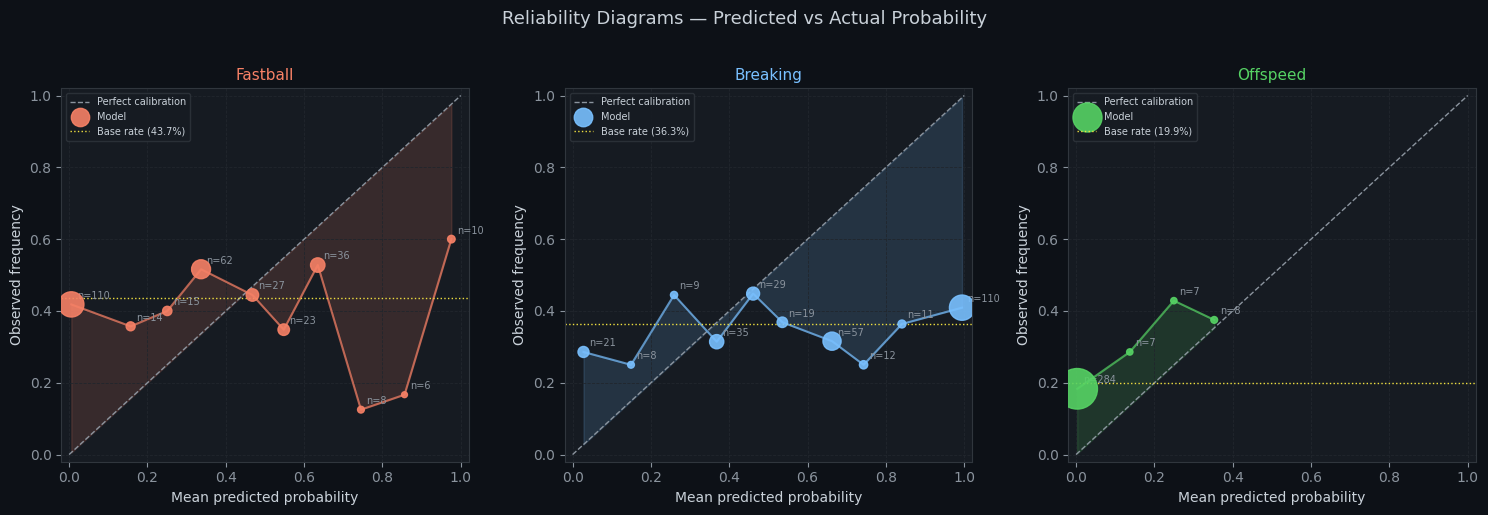


--- Mean predicted probability vs actual frequency per class ---
  Fastball   | mean predicted: 0.310  | actual frequency: 0.437  | gap: -0.127
  Breaking   | mean predicted: 0.662  | actual frequency: 0.363  | gap: +0.298
  Offspeed   | mean predicted: 0.028  | actual frequency: 0.199  | gap: -0.171


In [6]:
valid = lp[lp["probs_valid"]].copy()
print(f"Using {len(valid):,} valid rows for calibration analysis")

family_to_prob_col = {
    "Fastball": "prob_fastball",
    "Breaking": "prob_breaking",
    "Offspeed": "prob_offspeed",
}

N_BINS = 10
bins = np.linspace(0, 1, N_BINS + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Reliability Diagrams — Predicted vs Actual Probability", fontsize=13, y=1.02)

for ax, (family, prob_col) in zip(axes, family_to_prob_col.items()):
    pred_probs = valid[prob_col].values
    actuals    = (valid["actual_pitch_family"] == family).astype(int).values

    bin_idx  = np.digitize(pred_probs, bins) - 1
    bin_idx  = np.clip(bin_idx, 0, N_BINS - 1)

    bin_actual_rate = []
    bin_pred_mean   = []
    bin_counts      = []

    for b in range(N_BINS):
        mask = bin_idx == b
        if mask.sum() >= 5:  # require at least 5 samples per bin
            bin_actual_rate.append(actuals[mask].mean())
            bin_pred_mean.append(pred_probs[mask].mean())
            bin_counts.append(mask.sum())
        else:
            bin_actual_rate.append(np.nan)
            bin_pred_mean.append(bin_centers[b])
            bin_counts.append(0)

    bin_actual_rate = np.array(bin_actual_rate)
    bin_pred_mean   = np.array(bin_pred_mean)
    bin_counts      = np.array(bin_counts)

    color = FAMILY_COLORS.get(family, "white")

    # perfect calibration diagonal
    ax.plot([0, 1], [0, 1], linestyle="--", color="#8b949e", linewidth=1, label="Perfect calibration")

    # shaded gap between model and perfect
    valid_mask = ~np.isnan(bin_actual_rate)
    if valid_mask.sum() > 1:
        ax.fill_between(
            bin_pred_mean[valid_mask],
            bin_pred_mean[valid_mask],
            bin_actual_rate[valid_mask],
            alpha=0.15, color=color
        )

    # calibration line — size by bin count
    sc = ax.scatter(
        bin_pred_mean[valid_mask],
        bin_actual_rate[valid_mask],
        s=bin_counts[valid_mask] * 3,
        color=color, zorder=5, alpha=0.9,
        label="Model"
    )
    ax.plot(
        bin_pred_mean[valid_mask],
        bin_actual_rate[valid_mask],
        color=color, linewidth=1.5, alpha=0.7
    )

    # annotate bin counts
    for x_val, y_val, n in zip(bin_pred_mean[valid_mask], bin_actual_rate[valid_mask], bin_counts[valid_mask]):
        ax.annotate(f"n={n}", (x_val, y_val), textcoords="offset points",
                    xytext=(4, 4), fontsize=7, color="#8b949e")

    actual_freq = actuals.mean()
    ax.axhline(actual_freq, color="#f0e040", linestyle=":", linewidth=1,
               label=f"Base rate ({actual_freq:.1%})")

    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title(family, color=color, fontsize=11)
    ax.legend(fontsize=7)
    ax.grid(True)

plt.tight_layout()
plt.show()

# summary table
print("\n--- Mean predicted probability vs actual frequency per class ---")
for family, prob_col in family_to_prob_col.items():
    mean_pred = valid[prob_col].mean()
    actual_freq = (valid["actual_pitch_family"] == family).mean()
    print(f"  {family:<10} | mean predicted: {mean_pred:.3f}  | actual frequency: {actual_freq:.3f}  | gap: {mean_pred - actual_freq:+.3f}")

## 3. Surprisal Distribution

**Surprisal** (`-log2(P(actual))`) measures how surprised the model was by each pitch. It's our primary tweet trigger — pitches above `SURPRISAL_THRESHOLD = 2.5 bits` are candidates for tweeting.

- **0 bits** — model was certain and correct
- **1 bit** — model predicted 50/50 and was right
- **2.5 bits** — threshold (model was ≤17.7% confident in what was actually thrown)
- **∞** — model assigned 0% probability to the thrown pitch

A healthy distribution has most pitches clustered below the threshold, with a meaningful tail above it (good tweet candidates), but not too many `Inf` values.

Finite surprisal rows: 221 / 311 valid rows (71.1%)
Rows above tweet threshold (2.5 bits): 21 (9.5%)


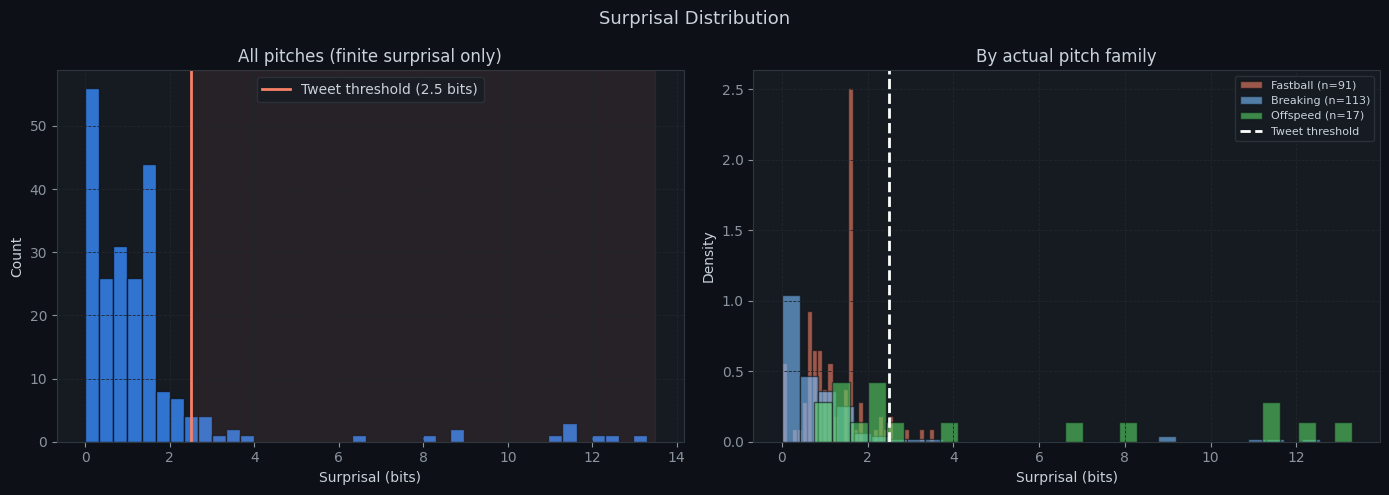


--- Surprisal stats by actual pitch family ---


,n,mean_bits,median_bits,std_bits,pct_above_threshold
actual_pitch_family,,,,,
Breaking,113,1.068,0.580,2.199,0.071
Fastball,91,1.252,1.186,0.692,0.055
Offspeed,17,5.018,2.346,4.529,0.471


In [7]:
finite = valid[valid["surprisal_finite"]].copy()
print(f"Finite surprisal rows: {len(finite)} / {len(valid)} valid rows ({len(finite)/len(valid)*100:.1f}%)")
print(f"Rows above tweet threshold ({SURPRISAL_THRESHOLD} bits): "
      f"{(finite['surprisal'] > SURPRISAL_THRESHOLD).sum()} ({(finite['surprisal'] > SURPRISAL_THRESHOLD).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Surprisal Distribution", fontsize=13)

# ── left: overall histogram ────────────────────────────────────────────────
ax = axes[0]
ax.hist(finite["surprisal"], bins=40, color="#388bfd", alpha=0.8, edgecolor="#0d1117")
ax.axvline(SURPRISAL_THRESHOLD, color="#f78166", linewidth=2,
           label=f"Tweet threshold ({SURPRISAL_THRESHOLD} bits)")
ax.set_xlabel("Surprisal (bits)")
ax.set_ylabel("Count")
ax.set_title("All pitches (finite surprisal only)")
ax.legend()
ax.grid(True)

# annotate tweet zone
ymax = ax.get_ylim()[1]
ax.fill_betweenx([0, ymax], SURPRISAL_THRESHOLD, finite["surprisal"].max() + 0.2,
                 alpha=0.08, color="#f78166", label="Tweet zone")
ax.set_ylim(0, ymax)

# ── right: per-family ──────────────────────────────────────────────────────
ax = axes[1]
for family, color in FAMILY_COLORS.items():
    subset = finite[finite["actual_pitch_family"] == family]["surprisal"]
    if len(subset) > 5:
        ax.hist(subset, bins=30, color=color, alpha=0.6,
                edgecolor="#0d1117", label=f"{family} (n={len(subset)})", density=True)
ax.axvline(SURPRISAL_THRESHOLD, color="white", linewidth=2, linestyle="--",
           label=f"Tweet threshold")
ax.set_xlabel("Surprisal (bits)")
ax.set_ylabel("Density")
ax.set_title("By actual pitch family")
ax.legend(fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.show()

# per-family surprisal stats
print("\n--- Surprisal stats by actual pitch family ---")
display(
    finite.groupby("actual_pitch_family")["surprisal"]
          .agg(["count","mean","median","std",
                ("pct_above_threshold", lambda s: (s > SURPRISAL_THRESHOLD).mean())])
          .round(3)
          .rename(columns={"count": "n", "mean": "mean_bits", "median": "median_bits", "std": "std_bits"})
)

## 4. Prediction Accuracy & Confusion Analysis

Here we treat this as a standard classification problem: **predicted family = argmax(prob_fastball, prob_breaking, prob_offspeed)** vs actual.

This is deliberately a coarser view than calibration — it tells us whether the model is *directionally* right, not whether the probabilities are well-calibrated.

We also look at **confidence buckets**: when the model is highly confident (e.g., >80% on one class), is it more or less accurate?

Evaluation set: 311 pitches
Overall accuracy: 39.2%

Classification report:
              precision    recall  f1-score   support

    Fastball       0.42      0.27      0.33       136
    Breaking       0.38      0.73      0.50       113
    Offspeed       0.67      0.03      0.06        62

    accuracy                           0.39       311
   macro avg       0.49      0.35      0.30       311
weighted avg       0.45      0.39      0.34       311



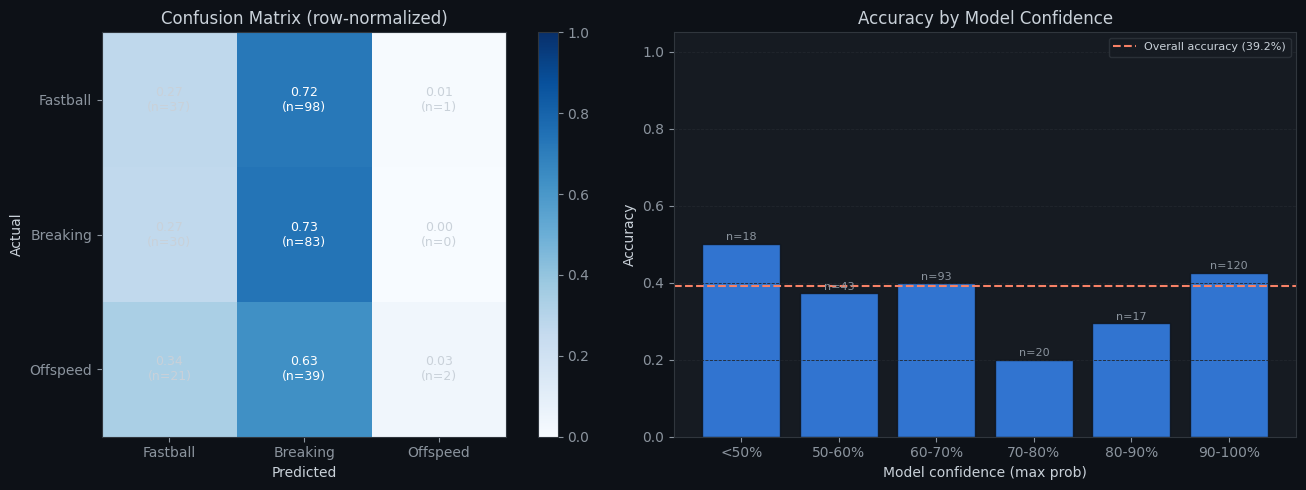

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

eval_df = valid[valid["actual_pitch_family"].isin(["Fastball", "Breaking", "Offspeed"])].copy()
classes = ["Fastball", "Breaking", "Offspeed"]

print(f"Evaluation set: {len(eval_df):,} pitches")
print(f"Overall accuracy: {eval_df['correct'].mean()*100:.1f}%")
print("\nClassification report:")
print(classification_report(eval_df["actual_pitch_family"], eval_df["predicted_family"],
                             labels=classes, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── confusion matrix ───────────────────────────────────────────────────────
ax = axes[0]
cm = confusion_matrix(eval_df["actual_pitch_family"], eval_df["predicted_family"], labels=classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes)
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (row-normalized)")
plt.colorbar(im, ax=ax)

for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f"{cm_norm[i,j]:.2f}\n(n={cm[i,j]})",
                ha="center", va="center",
                color="white" if cm_norm[i,j] > 0.5 else "#c9d1d9", fontsize=9)

# ── accuracy by model confidence ───────────────────────────────────────────
ax = axes[1]
eval_df["max_prob"] = eval_df[["prob_fastball","prob_breaking","prob_offspeed"]].max(axis=1)
eval_df["confidence_bucket"] = pd.cut(eval_df["max_prob"], bins=[0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                      labels=["<50%","50-60%","60-70%","70-80%","80-90%","90-100%"])
conf_acc = eval_df.groupby("confidence_bucket", observed=True).agg(
    accuracy=("correct", "mean"),
    n=("correct", "count")
).reset_index()

bars = ax.bar(conf_acc["confidence_bucket"].astype(str), conf_acc["accuracy"],
              color="#388bfd", alpha=0.8, edgecolor="#0d1117")
for bar, row in zip(bars, conf_acc.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"n={row.n}", ha="center", fontsize=8, color="#8b949e")

ax.axhline(eval_df["correct"].mean(), color="#f78166", linestyle="--",
           linewidth=1.5, label=f"Overall accuracy ({eval_df['correct'].mean():.1%})")
ax.set_xlabel("Model confidence (max prob)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Model Confidence")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.grid(True, axis="y")

plt.tight_layout()
plt.show()

## 5. Pitcher Coverage & Sample Gate

The sample gate (`MIN_PITCHER_SAMPLE = 75`) prevents predictions for pitchers with insufficient historical data. 

Rows logged after the gate was deployed (April 13+) have `pitcher_sample_n` populated. We can use those rows to understand:
- What the sample size distribution looks like for pitchers we're predicting on
- How many rows *would* have been filtered if the gate was active earlier (using `pitches` table as ground truth)
- Which specific pitchers have high `Inf` surprisal rates, suggesting model failure

Rows with pitcher_sample_n: 51 (logged after gate was deployed)


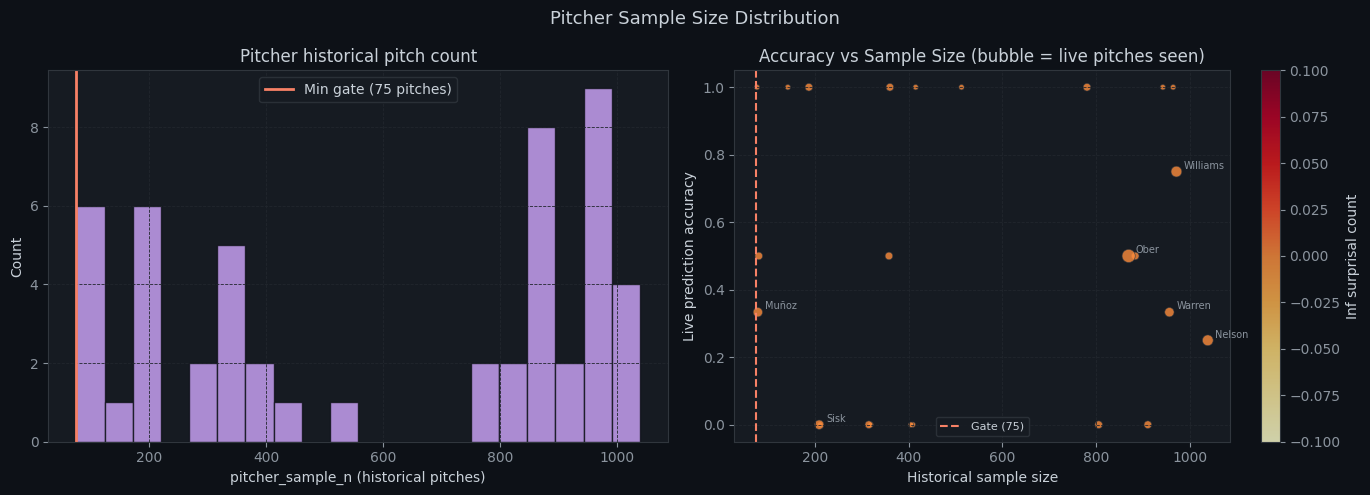


--- Pitcher detail table ---


,pitcher_id,pitcher_name,sample_n,live_pitches,inf_surprisal_n,accuracy
3,641927,Bailey Ober,870.0,6,0,0.500000
9,669194,Ryne Nelson,1039.0,4,0,0.250000
8,668909,Gavin Williams,972.0,4,0,0.750000
19,691548,Rolddy Muñoz,78.0,3,0,0.333333
23,701542,Will Warren,957.0,3,0,0.333333
15,681895,Evan Sisk,209.0,3,0,0.000000
1,607481,Aaron Bummer,187.0,2,0,1.000000
18,689147,Orion Kerkering,358.0,2,0,0.500000
6,664854,Ryan Helsley,360.0,2,0,1.000000
7,665152,Dean Kremer,806.0,2,0,0.000000



--- Retroactive gate simulation (using pitches table) ---


Would pass gate: 432 (96.6%)
Would fail gate: 15 (3.4%)
Unknown pitcher: 0 (0.0%)


In [9]:
# ── pitchers with sample_n populated ──────────────────────────────────────
gated_rows = lp[lp["pitcher_sample_n"].notna()].copy()
print(f"Rows with pitcher_sample_n: {len(gated_rows)} (logged after gate was deployed)")

if len(gated_rows) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Pitcher Sample Size Distribution", fontsize=13)

    ax = axes[0]
    ax.hist(gated_rows["pitcher_sample_n"], bins=20, color="#d2a8ff", alpha=0.8, edgecolor="#0d1117")
    ax.axvline(MIN_PITCHER_SAMPLE, color="#f78166", linewidth=2,
               label=f"Min gate ({MIN_PITCHER_SAMPLE} pitches)")
    ax.set_xlabel("pitcher_sample_n (historical pitches)")
    ax.set_ylabel("Count")
    ax.set_title("Pitcher historical pitch count")
    ax.legend()
    ax.grid(True)

    ax = axes[1]
    pitcher_stats = gated_rows.groupby(["pitcher_id","pitcher_name"]).agg(
        sample_n        = ("pitcher_sample_n", "first"),
        live_pitches    = ("id", "count"),
        inf_surprisal_n = ("surprisal_finite", lambda s: (~s).sum()),
        accuracy        = ("correct", "mean"),
    ).reset_index().sort_values("sample_n", ascending=False)

    sc = ax.scatter(
        pitcher_stats["sample_n"],
        pitcher_stats["accuracy"],
        s=pitcher_stats["live_pitches"] * 15,
        c=pitcher_stats["inf_surprisal_n"],
        cmap="YlOrRd", alpha=0.8,
        edgecolors="#30363d", linewidths=0.5
    )
    plt.colorbar(sc, ax=ax, label="Inf surprisal count")
    ax.axvline(MIN_PITCHER_SAMPLE, color="#f78166", linewidth=1.5, linestyle="--",
               label=f"Gate ({MIN_PITCHER_SAMPLE})")

    for _, row in pitcher_stats.iterrows():
        if row["live_pitches"] >= 3:
            name_short = " ".join(str(row["pitcher_name"]).split()[-1:]) if pd.notna(row["pitcher_name"]) else str(row["pitcher_id"])
            ax.annotate(name_short, (row["sample_n"], row["accuracy"]),
                        textcoords="offset points", xytext=(5, 2),
                        fontsize=7, color="#8b949e")

    ax.set_xlabel("Historical sample size")
    ax.set_ylabel("Live prediction accuracy")
    ax.set_title("Accuracy vs Sample Size (bubble = live pitches seen)")
    ax.legend(fontsize=8)
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    print("\n--- Pitcher detail table ---")
    display(pitcher_stats.sort_values("live_pitches", ascending=False).head(20))
else:
    print("No rows with pitcher_sample_n yet. Run the live tracker to populate.")

# ── retroactive gate simulation: how many pre-gate rows would be filtered? ─
print("\n--- Retroactive gate simulation (using pitches table) ---")
with sqlite3.connect(DB_PATH) as conn:
    pitcher_history = pd.read_sql_query(
        "SELECT pitcher_id, COUNT(*) as total_n FROM pitches GROUP BY pitcher_id",
        conn
    )

all_with_hist = lp.merge(pitcher_history, on="pitcher_id", how="left")
would_pass = (all_with_hist["total_n"] >= MIN_PITCHER_SAMPLE).sum()
would_fail = (all_with_hist["total_n"] < MIN_PITCHER_SAMPLE).sum()
unknown    = all_with_hist["total_n"].isna().sum()
print(f"Would pass gate: {would_pass} ({would_pass/len(lp)*100:.1f}%)")
print(f"Would fail gate: {would_fail} ({would_fail/len(lp)*100:.1f}%)")
print(f"Unknown pitcher: {unknown} ({unknown/len(lp)*100:.1f}%)")

## 6. Monitoring Summary

A concise snapshot of the key metrics — designed to be reviewed before each game day.

In [10]:
valid_rate   = lp["probs_valid"].mean()
finite_rate  = lp["surprisal_finite"].mean()
tweet_rate   = (finite["surprisal"] > SURPRISAL_THRESHOLD).mean() if len(finite) > 0 else float("nan")
overall_acc  = eval_df["correct"].mean() if len(eval_df) > 0 else float("nan")

# per-class accuracy
class_acc = {}
for fam in ["Fastball", "Breaking", "Offspeed"]:
    subset = eval_df[eval_df["actual_pitch_family"] == fam]
    class_acc[fam] = subset["correct"].mean() if len(subset) > 0 else float("nan")

print("═" * 55)
print("  MLB Pitch Bot — Model Monitoring Summary")
print(f"  {lp['date'].min()} → {lp['date'].max()}")
print("═" * 55)
print(f"  Total predictions logged : {len(lp):,}")
print(f"  Pitchers seen            : {lp['pitcher_id'].nunique()}")
print()
print("  Data Quality")
print(f"    Valid probability rate : {valid_rate:.1%}")
print(f"    Finite surprisal rate  : {finite_rate:.1%}")
print()
print("  Model Performance")
print(f"    Overall accuracy       : {overall_acc:.1%}")
for fam, acc in class_acc.items():
    print(f"    {fam:<10} accuracy  : {acc:.1%}")
print()
print("  Tweet Engine")
print(f"    Surprisal threshold    : {SURPRISAL_THRESHOLD} bits")
print(f"    Rows above threshold   : {tweet_rate:.1%} of finite-surprisal rows")
print()
print("  Sample Gate")
print(f"    Min pitcher sample     : {MIN_PITCHER_SAMPLE} pitches")
print(f"    Rows with sample_n     : {lp['pitcher_sample_n'].notna().sum()} / {len(lp)}")
print("═" * 55)

═══════════════════════════════════════════════════════
  MLB Pitch Bot — Model Monitoring Summary
  2026-04-05 → 2026-04-14
═══════════════════════════════════════════════════════
  Total predictions logged : 447
  Pitchers seen            : 167

  Data Quality
    Valid probability rate : 69.6%
    Finite surprisal rate  : 49.7%

  Model Performance
    Overall accuracy       : 39.2%
    Fastball   accuracy  : 27.2%
    Breaking   accuracy  : 73.5%
    Offspeed   accuracy  : 3.2%

  Tweet Engine
    Surprisal threshold    : 2.5 bits
    Rows above threshold   : 9.5% of finite-surprisal rows

  Sample Gate
    Min pitcher sample     : 75 pitches
    Rows with sample_n     : 51 / 447
═══════════════════════════════════════════════════════


## 6b. Pre/Post-Fix Pipeline Analysis

The aggregate metrics above are skewed by **legacy data logged before two pipeline fixes deployed on 2026-04-13**:

1. **DB logging bug** -- probabilities stored as `0.0` due to a type-coercion error. Rows with `prob_breaking=1.0, prob_fastball=0.0, prob_offspeed=0.0` appear valid (sum=1.0) but are degenerate.
2. **Sample gate** -- `MIN_PITCHER_SAMPLE=75` added on the same date; `pitcher_sample_n IS NOT NULL` is a clean proxy for the current pipeline.

**Key question:** does the *current* pipeline have a Breaking bias and Inf surprisal problem, or is it a legacy artifact?

> **Offspeed finding:** even in post-fix data, only ~20% of Offspeed pitches are predicted correctly (argmax). This is a real model issue -- training data is only 14.3% Offspeed with no class balancing. The fix is to add class-balanced sample weights in `train_model.py` before the next retrain.

Pre-fix rows  (before 2026-04-13): 396
Post-fix rows (from   2026-04-13): 51

  PRE-FIX  (396 rows, 260 valid-prob rows)
  Valid prob rate         : 65.7%
  Finite surprisal rate   : 43.2%
  Mean pred prob Breaking : 0.716
  Overall accuracy        : 37.7%
    Fastball   recall: 23.3%  mean pred prob: 0.289  n=120
    Breaking   recall: 79.5%  mean pred prob: 0.754  n=88
    Offspeed   recall: 0.0%  mean pred prob: 0.012  n=52

  POST-FIX  (51 rows, 51 valid-prob rows)
  Valid prob rate         : 100.0%
  Finite surprisal rate   : 100.0%
  Mean pred prob Breaking : 0.385
  Overall accuracy        : 47.1%
    Fastball   recall: 56.2%  mean pred prob: 0.480  n=16
    Breaking   recall: 52.0%  mean pred prob: 0.437  n=25
    Offspeed   recall: 20.0%  mean pred prob: 0.261  n=10


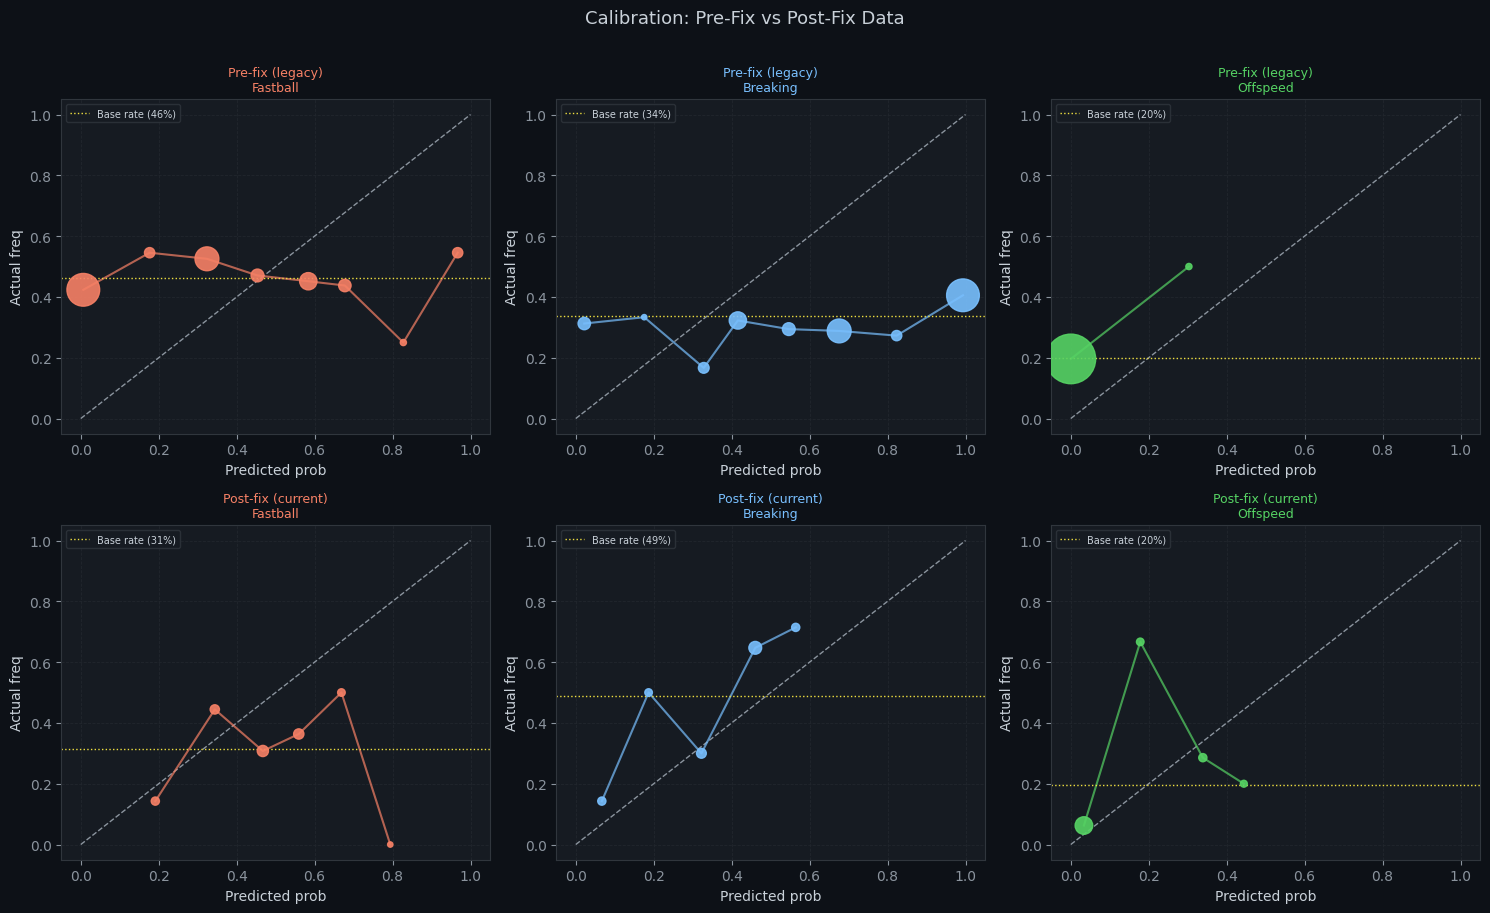

In [11]:
# ── split on pipeline fix date ────────────────────────────────────────────
FIX_DATE = "2026-04-13"
pre  = lp[lp["date"] < FIX_DATE].copy()
post = lp[lp["date"] >= FIX_DATE].copy()

print(f"Pre-fix rows  (before {FIX_DATE}): {len(pre):,}")
print(f"Post-fix rows (from   {FIX_DATE}): {len(post):,}")

for label, subset in [("PRE-FIX", pre), ("POST-FIX", post)]:
    valid_s = subset[subset["probs_valid"]]
    print(f"\n{'='*52}")
    print(f"  {label}  ({len(subset):,} rows, {len(valid_s):,} valid-prob rows)")
    print(f"{'='*52}")
    print(f"  Valid prob rate         : {subset['probs_valid'].mean():.1%}")
    print(f"  Finite surprisal rate   : {subset['surprisal_finite'].mean():.1%}")
    if len(valid_s) > 0:
        print(f"  Mean pred prob Breaking : {valid_s['prob_breaking'].mean():.3f}")
        print(f"  Overall accuracy        : {valid_s['correct'].mean():.1%}")
        for fam in ["Fastball", "Breaking", "Offspeed"]:
            fam_s = valid_s[valid_s["actual_pitch_family"] == fam]
            if len(fam_s) > 0:
                recall = fam_s["correct"].mean()
                mean_p = fam_s[f"prob_{fam.lower()}"].mean()
                print(f"    {fam:<10} recall: {recall:.1%}  mean pred prob: {mean_p:.3f}  n={len(fam_s)}")

# ── side-by-side calibration: pre vs post ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Calibration: Pre-Fix vs Post-Fix Data", fontsize=13, y=1.01)

family_to_prob_col = {
    "Fastball": "prob_fastball",
    "Breaking": "prob_breaking",
    "Offspeed": "prob_offspeed",
}
N_BINS = 8
bins = np.linspace(0, 1, N_BINS + 1)

for row_idx, (label, subset) in enumerate([("Pre-fix (legacy)", pre), ("Post-fix (current)", post)]):
    valid_s = subset[subset["probs_valid"]].copy()
    for col_idx, (family, prob_col) in enumerate(family_to_prob_col.items()):
        ax = axes[row_idx][col_idx]
        color = FAMILY_COLORS.get(family, "white")

        if len(valid_s) < 10:
            ax.text(0.5, 0.5, "insufficient data", ha="center", va="center",
                    transform=ax.transAxes, color="#8b949e")
        else:
            pred_probs = valid_s[prob_col].values
            actuals    = (valid_s["actual_pitch_family"] == family).astype(int).values
            bin_idx    = np.clip(np.digitize(pred_probs, bins) - 1, 0, N_BINS - 1)

            xs, ys, ns = [], [], []
            for b in range(N_BINS):
                mask = bin_idx == b
                if mask.sum() >= 3:
                    xs.append(pred_probs[mask].mean())
                    ys.append(actuals[mask].mean())
                    ns.append(mask.sum())

            ax.plot([0, 1], [0, 1], "--", color="#8b949e", linewidth=1)
            if xs:
                ax.scatter(xs, ys, s=[n * 5 for n in ns], color=color, zorder=5, alpha=0.9)
                ax.plot(xs, ys, color=color, linewidth=1.5, alpha=0.7)
            ax.axhline(actuals.mean(), color="#f0e040", linestyle=":", linewidth=1,
                       label=f"Base rate ({actuals.mean():.0%})")
            ax.legend(fontsize=7)

        ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel("Predicted prob"); ax.set_ylabel("Actual freq")
        ax.set_title(f"{label}\n{family}", color=color, fontsize=9)
        ax.grid(True)

plt.tight_layout()
plt.show()

## 7. W&B Integration (Stub)

Once we've confirmed which metrics matter (via this notebook), we'll log them in real-time to **Weights & Biases** during live inference.

### Architecture

There are two natural integration points:

**A. Per-pitch online logging** (in `src/live_game_tracker.py`)
```python
wandb.log({
    "surprisal":           surprisal,
    "prob_fastball":       probabilities["Fastball"],
    "prob_breaking":       probabilities["Breaking"],
    "prob_offspeed":       probabilities["Offspeed"],
    "actual_family":       actual_pitch_family,
    "predicted_correct":   (predicted_family == actual_pitch_family),
    "tweeted":             surprisal > SURPRISAL_THRESHOLD,
    "pitcher_sample_n":    pitcher_sample_n,
    "count_sample_n":      count_sample_n,
})
```

**B. Nightly batch logging** (run this notebook as a script)
```python
import wandb

run = wandb.init(
    project="mlb-pitch-bot",
    name=f"monitoring-{today}",
    job_type="monitoring"
)

# log a W&B Table for the full day's predictions
table = wandb.Table(dataframe=lp[lp["date"] == today_str])
run.log({"predictions": table})

# log scalar summaries
run.log({
    "valid_prob_rate":    valid_rate,
    "finite_surprisal_rate": finite_rate,
    "overall_accuracy":  overall_acc,
    "tweet_rate":         tweet_rate,
    **{f"accuracy_{fam.lower()}": acc for fam, acc in class_acc.items()}
})

# log calibration as a custom chart
# (use wandb.plot.line_series for the reliability diagram)

run.finish()
```

### What W&B adds beyond this notebook

| Capability | Notebook | W&B |
|---|---|---|
| Historical comparison across days | Manual | Automatic |
| Alerts when accuracy drops | Manual check | Configurable alerts |
| Calibration drift over the season | Re-run notebook | Always-on dashboard |
| Per-pitch data explorer | SQL query | Interactive table UI |
| Shareable dashboard | No | Yes |

### Next step
Run `pip install wandb`, then enable per-pitch logging in `live_game_tracker.py` using the snippet above. The nightly batch run can be scheduled via `cron` or GitHub Actions.